In [3]:
import numpy as np

def softmax(x):
    # 对最后一个维度做softmax
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores)
    output = weights @ V
    return output, weights  # 把weights也返回，之后可视化用

In [4]:
# 造一个最简单的例子
# 假设我们有3个词，每个词用4维向量表示
np.random.seed(42)
Q = np.random.randn(3, 4)
K = np.random.randn(3, 4)
V = np.random.randn(3, 4)

output, weights = scaled_dot_product_attention(Q, K, V)

print("注意力权重矩阵 (3x3):")
print(np.round(weights, 3))
print("\n每行加起来是否等于1:")
print(np.round(weights.sum(axis=-1), 3))

注意力权重矩阵 (3x3):
[[0.393 0.168 0.439]
 [0.231 0.283 0.486]
 [0.225 0.559 0.216]]

每行加起来是否等于1:
[1. 1. 1.]


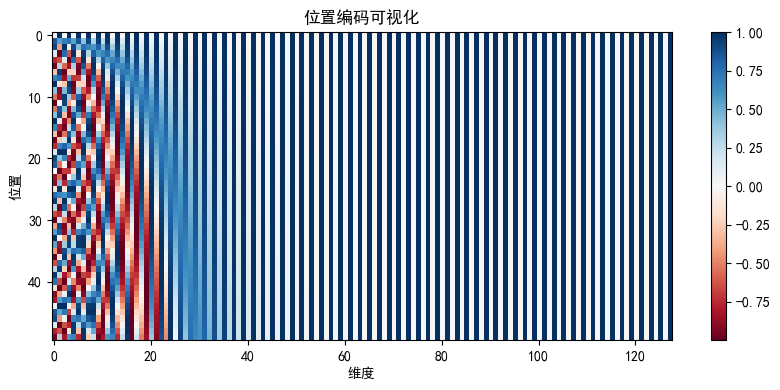

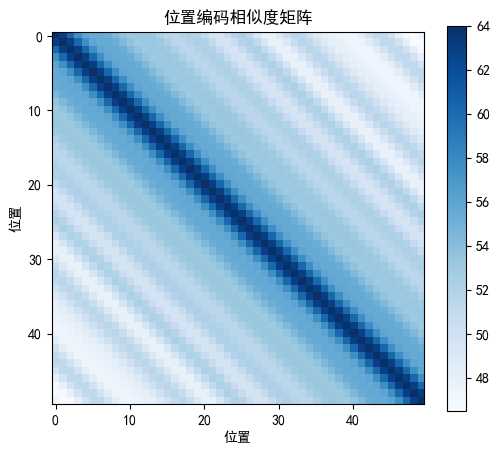

In [6]:
def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            PE[pos, i]   = np.sin(pos / 10000 ** (2*i / d_model))
            PE[pos, i+1] = np.cos(pos / 10000 ** (2*i / d_model))
    return PE

# 可视化一下
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False

PE = positional_encoding(50, 128)
plt.figure(figsize=(10, 4))
plt.imshow(PE, aspect='auto', cmap='RdBu')
plt.colorbar()
plt.xlabel("维度")
plt.ylabel("位置")
plt.title("位置编码可视化")
plt.show()

# 计算所有位置两两之间的相似度
similarity = PE @ PE.T

plt.figure(figsize=(6, 5))
plt.imshow(similarity, cmap='Blues')
plt.colorbar()
plt.title("位置编码相似度矩阵")
plt.xlabel("位置")
plt.ylabel("位置")
plt.show()

In [7]:
def multi_head_attention(Q, K, V, h=8):
    d_model = Q.shape[-1]
    d_k = d_model // h
    
    # 为每个头生成随机投影矩阵（训练时这些是可学习的参数）
    np.random.seed(0)
    WQ = [np.random.randn(d_model, d_k) for _ in range(h)]
    WK = [np.random.randn(d_model, d_k) for _ in range(h)]
    WV = [np.random.randn(d_model, d_k) for _ in range(h)]
    WO = np.random.randn(h * d_k, d_model)
    
    heads = []
    all_weights = []
    
    for i in range(h):
        # 每个头用不同的矩阵把Q/K/V投影到低维
        Qi = Q @ WQ[i]  # (seq_len, d_k)
        Ki = K @ WK[i]
        Vi = V @ WV[i]
        
        head_output, weights = scaled_dot_product_attention(Qi, Ki, Vi)
        heads.append(head_output)
        all_weights.append(weights)
    
    # 拼接所有头的输出，再投影回d_model维
    concat = np.concatenate(heads, axis=-1)  # (seq_len, h*d_k)
    output = concat @ WO
    
    return output, all_weights  # all_weights是8个3x3矩阵

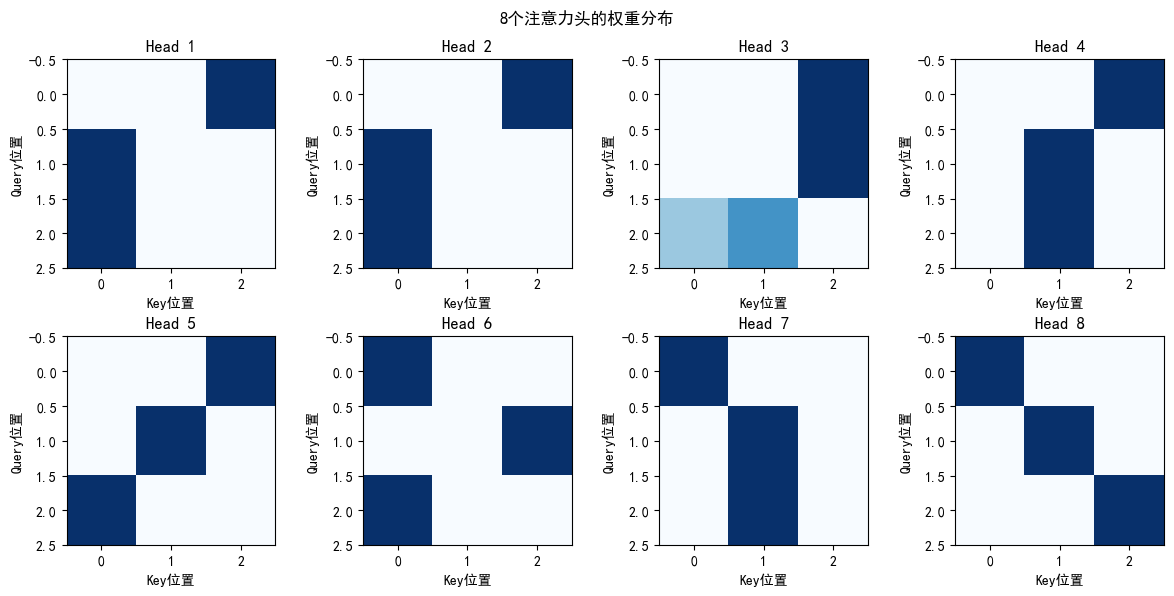

In [8]:
# 随机输入，3个词，512维
np.random.seed(42)
X = np.random.randn(3, 512)

output, all_weights = multi_head_attention(X, X, X)

# 画8个头的注意力权重
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(all_weights[i], cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Head {i+1}')
    ax.set_xlabel('Key位置')
    ax.set_ylabel('Query位置')
plt.suptitle('8个注意力头的权重分布')
plt.tight_layout()
plt.show()

In [9]:
def feed_forward(x, d_model=512, d_ff=2048):
    # 两个线性变换矩阵
    W1 = np.random.randn(d_model, d_ff) * 0.01
    W2 = np.random.randn(d_ff, d_model) * 0.01
    b1 = np.zeros(d_ff)
    b2 = np.zeros(d_model)
    
    # 第一层 + ReLU
    hidden = np.maximum(0, x @ W1 + b1)
    # 第二层
    output = hidden @ W2 + b2
    return output

In [10]:
def layer_norm(x, eps=1e-6):
    mean = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + eps)

def encoder_layer(x, h=8):
    d_model = x.shape[-1]
    
    # 第一个子层：Multi-Head Attention + 残差 + LayerNorm
    attn_output, weights = multi_head_attention(x, x, x, h)
    x = layer_norm(x + attn_output)
    
    # 第二个子层：Feed-Forward + 残差 + LayerNorm
    ff_output = feed_forward(x, d_model)
    x = layer_norm(x + ff_output)
    
    return x, weights

# 测试：3个词，512维
np.random.seed(42)
X = np.random.randn(3, 512)
output, weights = encoder_layer(X)

print("输入shape:", X.shape)
print("输出shape:", output.shape)
print("shape没有变化，符合预期")

输入shape: (3, 512)
输出shape: (3, 512)
shape没有变化，符合预期


In [11]:
def encoder(x, N=6, h=8):
    # 先加位置编码
    seq_len, d_model = x.shape
    x = x + positional_encoding(seq_len, d_model)
    
    # 过N个encoder层
    all_weights = []
    for _ in range(N):
        x, weights = encoder_layer(x, h)
        all_weights.append(weights)
    
    return x, all_weights

# 测试
np.random.seed(42)
X = np.random.randn(3, 512)
output, all_weights = encoder(X)

print("Encoder输出shape:", output.shape)
print("层数:", len(all_weights))
print("每层头数:", len(all_weights[0]))

Encoder输出shape: (3, 512)
层数: 6
每层头数: 8


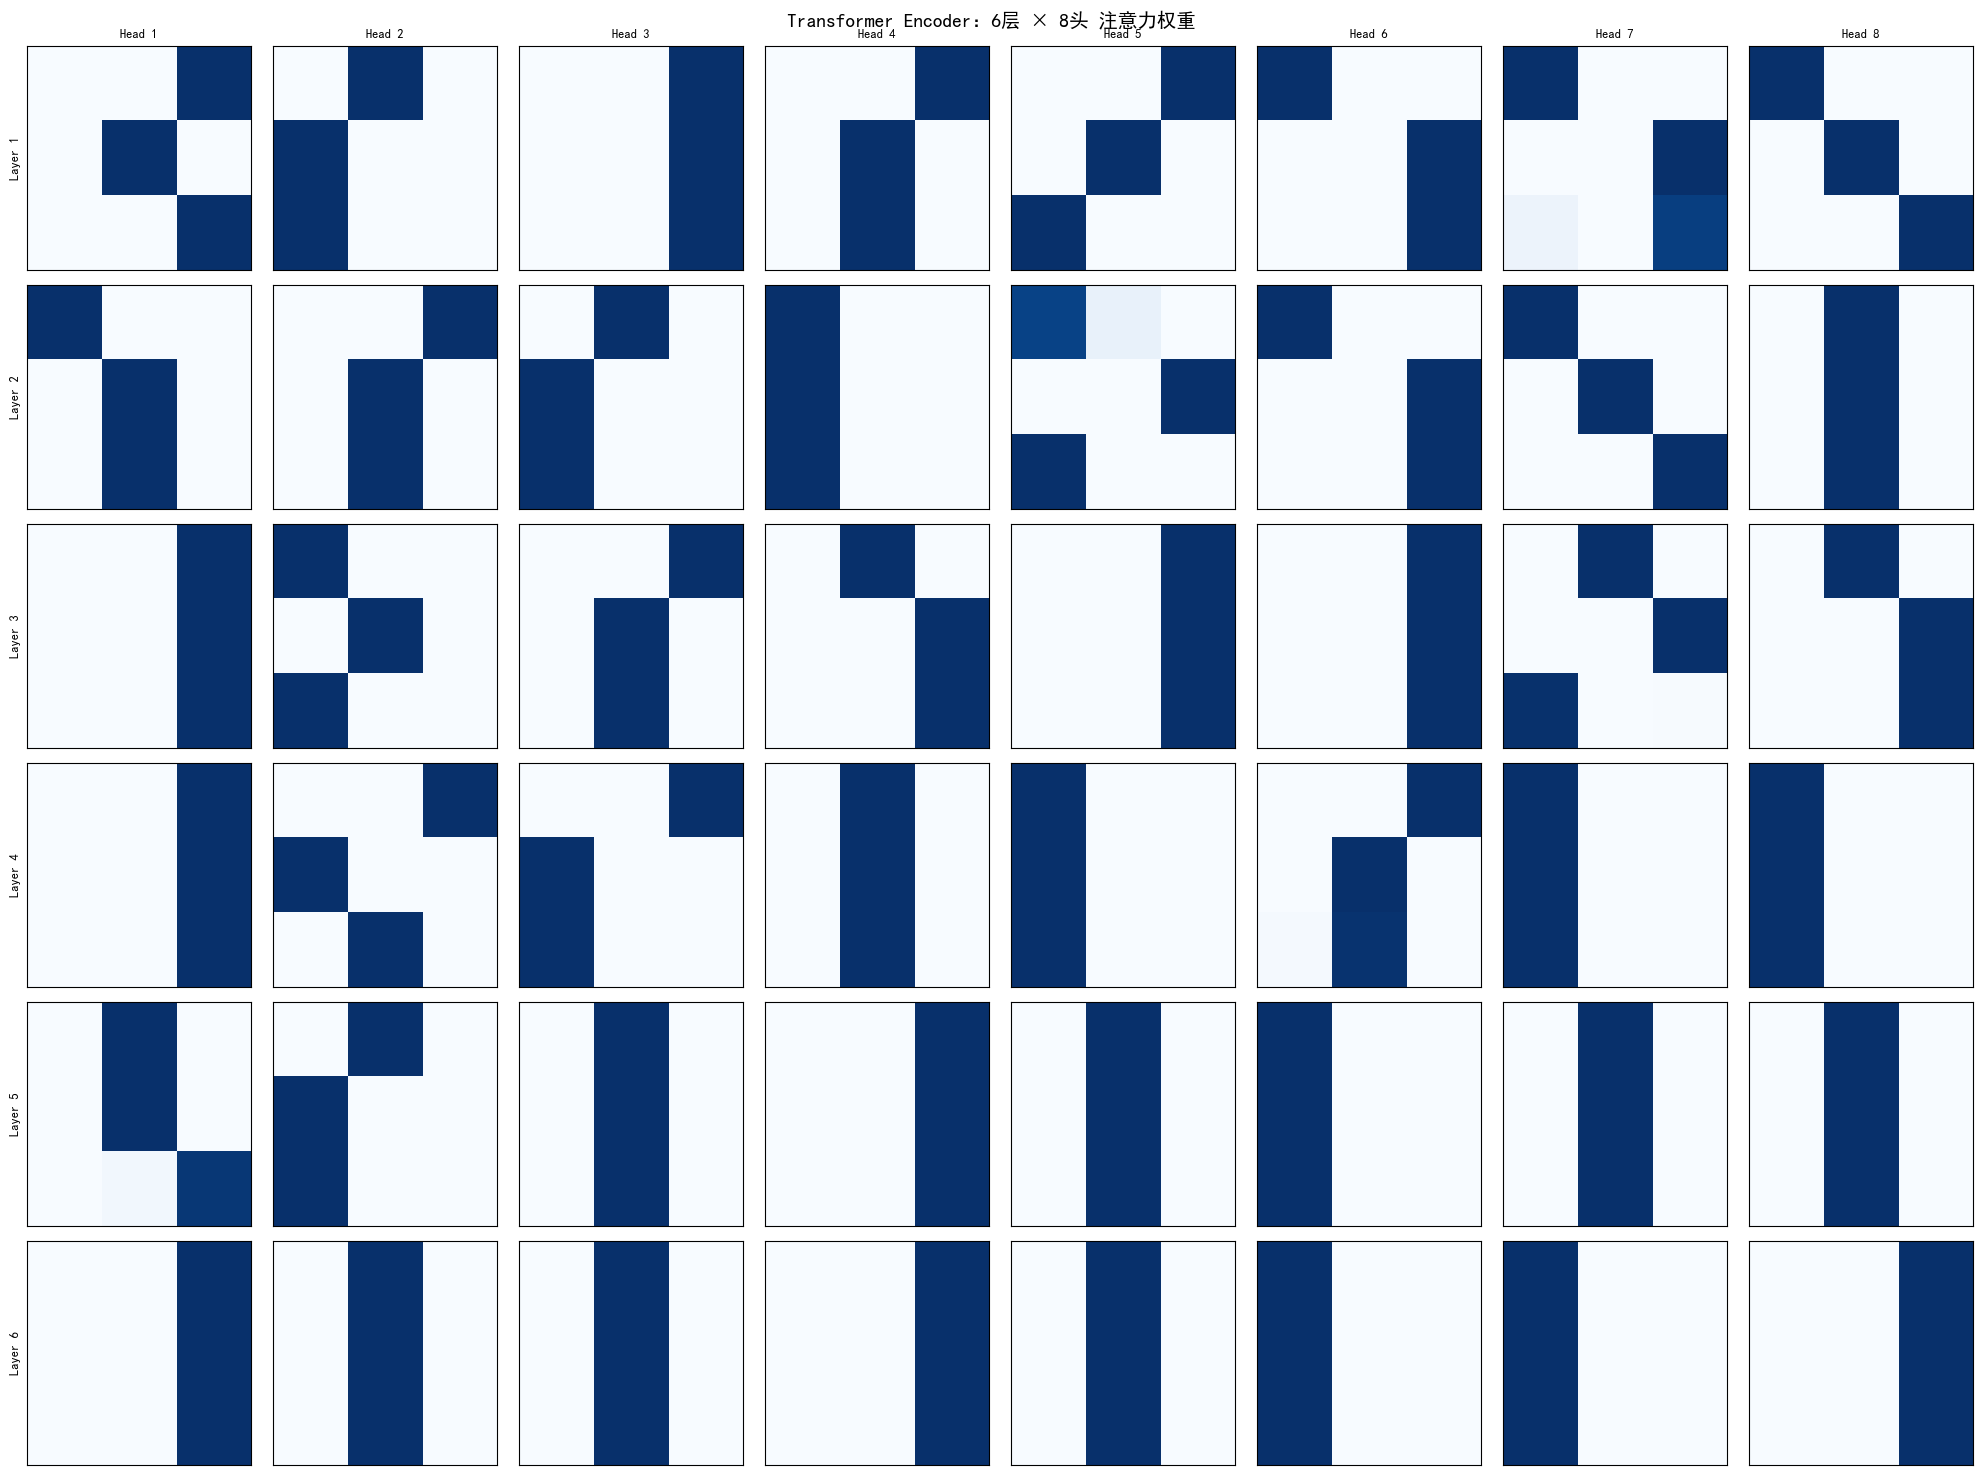

In [12]:
fig, axes = plt.subplots(6, 8, figsize=(20, 15))

for layer_idx in range(6):
    for head_idx in range(8):
        ax = axes[layer_idx][head_idx]
        im = ax.imshow(all_weights[layer_idx][head_idx], 
                      cmap='Blues', vmin=0, vmax=1)
        if layer_idx == 0:
            ax.set_title(f'Head {head_idx+1}', fontsize=9)
        if head_idx == 0:
            ax.set_ylabel(f'Layer {layer_idx+1}', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Transformer Encoder：6层 × 8头 注意力权重', fontsize=14)
plt.tight_layout()
plt.show()